# DINOv3 ViT-B Binary Tumor Classification (Colab)
## Tumor vs No Tumor | Medically Defensible Augmentation + SHA-256 Cleaned Data

Binary task: **tumor** (glioma, meningioma, pituitary merged) vs **no_tumor**.

Uses the same protocol as the 4-class A2 experiment:
- Exact duplicate removal (SHA-256)
- Medically defensible augmentation
- Last 4 transformer blocks unfrozen
- Validation macro-F1 checkpoint selection across seeds 42, 123, 2026
- Locked holdout test evaluation
- Paper-ready figures (training curves, confusion matrix, class-wise bars, ROC, CV)

**Requirements:** GPU runtime, HuggingFace token with access to `facebook/dinov3-vitb16-pretrain-lvd1689m`, and BRISC dataset zip at `/content/drive/MyDrive/Data/BT_Images.zip` (or edit path below).


In [1]:
# Install dependencies (Colab)
!pip -q install transformers huggingface_hub accelerate seaborn


In [2]:
import os, json, copy, shutil, random, hashlib, zipfile
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

CONFIG = {
    "model_id": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "img_size": 224,
    "hidden_dim": 768,
    "n_unfreeze_blocks": 4,
    "dropout": 0.3,
    "val_split": 0.15,
    "split_seed": 42,
    "seeds": [42, 123, 2026],
    "batch_size": 32,
    "num_workers": 2,
    "epochs_finetune": 25,
    "patience": 7,
    "lr_head": 1e-3,
    "lr_backbone": 1e-5,
    "weight_decay": 1e-4,
    "cv_folds": 5,
    "cv_seed": 42,
    "out_root": "results_dinov3_binary_medically_defensible",
    "task": "binary_tumor_vs_no_tumor",
}

# Binary labels: 0 = no_tumor, 1 = tumor (glioma + meningioma + pituitary)
CLASS_NAMES = ["no_tumor", "tumor"]
CLASS_DISPLAY = ["No Tumor", "Tumor"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
TUMOR_SUBTYPES = {"glioma", "meningioma", "pituitary"}
NUM_CLASSES = len(CLASS_NAMES)

def to_binary_label(multiclass_name: str) -> str:
    if multiclass_name == "no_tumor":
        return "no_tumor"
    if multiclass_name in TUMOR_SUBTYPES:
        return "tumor"
    raise ValueError(f"Unknown class for binary mapping: {multiclass_name}")

OUT_ROOT = Path(CONFIG["out_root"])
CKPT_DIR = OUT_ROOT / "checkpoints"
FIG_DIR = OUT_ROOT / "figures"
METRICS_DIR = OUT_ROOT / "metrics"
for p in (OUT_ROOT, CKPT_DIR, FIG_DIR, METRICS_DIR):
    p.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
with open(OUT_ROOT / "experiment_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)


Device: cuda
GPU: Tesla T4


In [3]:
# HuggingFace authentication
MANUAL_HF_TOKEN = ""  # optional: paste token here

if MANUAL_HF_TOKEN.strip():
    HF_TOKEN = MANUAL_HF_TOKEN.strip()
else:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("Set HF_TOKEN in Colab secrets or MANUAL_HF_TOKEN in this cell.")

from huggingface_hub import login, HfApi
login(token=HF_TOKEN, add_to_git_credential=False)
HfApi().model_info(CONFIG["model_id"], token=HF_TOKEN)
print("HuggingFace access confirmed.")


HuggingFace access confirmed.


In [4]:
# Dataset paths (edit if needed)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    ZIP_PATH = "/content/drive/MyDrive/Data/BT_Images.zip"
    RAW_ROOT = "/content/BRISC_raw"
    CLEAN_ROOT = "/content/BRISC_cleaned_binary_medically_defensible"
except Exception:
    ZIP_PATH = "./BT_Images.zip"
    RAW_ROOT = "./BRISC_raw"
    CLEAN_ROOT = "./BRISC_cleaned_binary_medically_defensible"

def sha256_of_file(filepath, chunk_size=65536):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

if os.path.exists(ZIP_PATH) and not os.path.exists(RAW_ROOT):
    print("Extracting dataset...")
    temp = "./_bt_extract_temp"
    if os.path.exists(temp):
        shutil.rmtree(temp)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(temp)
    items = os.listdir(temp)
    src_base = os.path.join(temp, items[0]) if len(items) == 1 and os.path.isdir(os.path.join(temp, items[0])) else temp
    folder_map = {}
    for d in os.listdir(src_base):
        dl = d.lower()
        full = os.path.join(src_base, d)
        if os.path.isdir(full):
            if "train" in dl:
                folder_map["train"] = full
            elif "test" in dl:
                folder_map["test"] = full
    os.makedirs(RAW_ROOT, exist_ok=True)
    shutil.copytree(folder_map["train"], os.path.join(RAW_ROOT, "train"))
    shutil.copytree(folder_map["test"], os.path.join(RAW_ROOT, "test"))
    shutil.rmtree(temp)
    print(f"Extracted to {RAW_ROOT}")
elif os.path.exists(RAW_ROOT):
    print(f"Using existing raw dataset: {RAW_ROOT}")
else:
    raise FileNotFoundError("Dataset not found. Upload BT_Images.zip or set RAW_ROOT.")

if os.path.exists(CLEAN_ROOT):
    shutil.rmtree(CLEAN_ROOT)
shutil.copytree(RAW_ROOT, CLEAN_ROOT)
print(f"Working copy: {CLEAN_ROOT}")


Mounted at /content/drive
Extracting dataset...
Extracted to /content/BRISC_raw
Working copy: /content/BRISC_cleaned_binary_medically_defensible


In [5]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def normalize_class_name(name):
    n = name.lower().strip()
    if "glioma" in n:
        return "glioma"
    if "meningioma" in n:
        return "meningioma"
    if "pituitary" in n:
        return "pituitary"
    if "no" in n:
        return "no_tumor"
    raise ValueError(name)

def list_images(split_dir):
    rows = []
    for class_dir in sorted(Path(split_dir).iterdir()):
        if not class_dir.is_dir():
            continue
        cls = normalize_class_name(class_dir.name)
        for fp in sorted(class_dir.iterdir()):
            if fp.suffix.lower() in VALID_EXT:
                rows.append((str(fp), cls))
    return rows

train_raw_rows = list_images(os.path.join(CLEAN_ROOT, "train"))
test_raw_rows = list_images(os.path.join(CLEAN_ROOT, "test"))
print(f"Raw indexed: train={len(train_raw_rows)}, test={len(test_raw_rows)}")

hash_to_entries = defaultdict(list)
for fp, cls in tqdm(train_raw_rows, desc="Hash train"):
    hash_to_entries[sha256_of_file(fp)].append({"path": fp, "split": "train", "class": cls})
for fp, cls in tqdm(test_raw_rows, desc="Hash test"):
    hash_to_entries[sha256_of_file(fp)].append({"path": fp, "split": "test", "class": cls})

duplicate_groups = {h: e for h, e in hash_to_entries.items() if len(e) > 1}
conflicts = [h for h, entries in duplicate_groups.items() if len({e["class"] for e in entries}) > 1]
if conflicts:
    raise RuntimeError(f"Label conflicts in duplicate groups: {len(conflicts)}")

to_remove = set()
cross_split_count = 0
for entries in duplicate_groups.values():
    train_e = [e for e in entries if e["split"] == "train"]
    test_e = [e for e in entries if e["split"] == "test"]
    if train_e and test_e:
        cross_split_count += 1
        to_remove.update(e["path"] for e in train_e)
        to_remove.update(e["path"] for e in test_e[1:])
    else:
        to_remove.update(e["path"] for e in entries[1:])

for fp in to_remove:
    Path(fp).unlink(missing_ok=True)

clean_train_rows = [(fp, cls) for fp, cls in train_raw_rows if fp not in to_remove]
clean_test_rows = [(fp, cls) for fp, cls in test_raw_rows if fp not in to_remove]
clean_train_fps = [fp for fp, _ in clean_train_rows]
clean_train_labels_int = [CLASS_TO_IDX[to_binary_label(cls)] for _, cls in clean_train_rows]
clean_test_fps = [fp for fp, _ in clean_test_rows]
clean_test_labels_int = [CLASS_TO_IDX[to_binary_label(cls)] for _, cls in clean_test_rows]

binary_counts = Counter(clean_train_labels_int + clean_test_labels_int)
print(
    "Binary label counts (train+test):",
    {CLASS_NAMES[i]: binary_counts.get(i, 0) for i in range(NUM_CLASSES)},
)

train_hashes = {sha256_of_file(fp) for fp in clean_train_fps}
test_hashes = {sha256_of_file(fp) for fp in clean_test_fps}
assert len(train_hashes & test_hashes) == 0, "Cross-split leakage remains!"

audit = {
    "cross_split_groups": cross_split_count,
    "total_removed": len(to_remove),
    "clean_train": len(clean_train_fps),
    "clean_test": len(clean_test_fps),
}
with open(METRICS_DIR / "exact_duplicate_audit.json", "w") as f:
    json.dump(audit, f, indent=2)
print(audit)


Raw indexed: train=5000, test=1000


Hash train:   0%|          | 0/5000 [00:00<?, ?it/s]

Hash test:   0%|          | 0/1000 [00:00<?, ?it/s]

Binary label counts (train+test): {'no_tumor': 1197, 'tumor': 4753}
{'cross_split_groups': 7, 'total_removed': 50, 'clean_train': 4955, 'clean_test': 995}


In [6]:
idx_train, idx_val = train_test_split(
    list(range(len(clean_train_fps))),
    test_size=CONFIG["val_split"],
    stratify=clean_train_labels_int,
    random_state=CONFIG["split_seed"],
)
train_fps = [clean_train_fps[i] for i in idx_train]
train_labs = [clean_train_labels_int[i] for i in idx_train]
val_fps = [clean_train_fps[i] for i in idx_val]
val_labs = [clean_train_labels_int[i] for i in idx_val]
test_fps, test_labs = clean_test_fps, clean_test_labels_int
print(f"Train={len(train_fps)}, Val={len(val_fps)}, Test={len(test_fps)}")


Train=4211, Val=744, Test=995


In [7]:
DINO_MEAN = [0.485, 0.456, 0.406]
DINO_STD = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=DINO_MEAN, std=DINO_STD),
])
transform_eval = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(mean=DINO_MEAN, std=DINO_STD),
])

class ImageListDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths, self.labels, self.transform = filepaths, labels, transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

def seed_worker(worker_id):
    w = torch.initial_seed() % 2**32
    np.random.seed(w)
    random.seed(w)


In [8]:
from transformers import AutoModel

class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class DINOv3Classifier(nn.Module):
    def __init__(self, backbone, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.head = MLPHead(hidden_dim, 256, num_classes, dropout)

    def forward(self, x):
        cls = self.backbone(x).last_hidden_state[:, 0]
        return self.head(cls)

def get_transformer_layers(backbone):
    for getter in [lambda m: m.encoder.layer, lambda m: m.encoder.layers, lambda m: m.layers]:
        try:
            blocks = getter(backbone)
            if isinstance(blocks, (nn.ModuleList, list, tuple)) and len(blocks):
                return blocks
        except Exception:
            pass
    return None

def unfreeze_last_n_blocks(model, n_blocks):
    for p in model.backbone.parameters():
        p.requires_grad = False
    blocks = get_transformer_layers(model.backbone)
    if blocks is not None:
        start = max(0, len(blocks) - n_blocks)
        for i in range(start, len(blocks)):
            for p in blocks[i].parameters():
                p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
    }

@torch.no_grad()
def evaluate_dataset(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        out = model(imgs)
        pr = torch.softmax(out, dim=1).cpu().numpy()
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbls.numpy() if torch.is_tensor(lbls) else lbls)
        probs.append(pr)
    preds = np.array(preds)
    labels = np.array(labels)
    probs = np.concatenate(probs)
    return preds, probs, labels, compute_metrics(labels, preds)

def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, epochs, patience, desc="train"):
    best_f1, best_loss, best_epoch, best_state = -1, float("inf"), 0, None
    patience_ctr = 0
    history = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "val_macro_f1", "lr"]}
    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, n, tr_p, tr_y = 0.0, 0, [], []
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            n += imgs.size(0)
            tr_p.extend(out.argmax(1).detach().cpu().numpy())
            tr_y.extend(lbls.detach().cpu().numpy())
        train_loss = run_loss / n
        train_acc = accuracy_score(tr_y, tr_p)
        model.eval()
        vl, vn, va_p, va_y = 0.0, 0, [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                loss = criterion(out, lbls)
                vl += loss.item() * imgs.size(0)
                vn += imgs.size(0)
                va_p.extend(out.argmax(1).cpu().numpy())
                va_y.extend(lbls.cpu().numpy())
        val_loss = vl / vn
        val_acc = accuracy_score(va_y, va_p)
        val_f1 = f1_score(va_y, va_p, average="macro", zero_division=0)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_f1)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        if scheduler:
            scheduler.step(val_loss)
        improved = val_f1 > best_f1 + 1e-5 or (abs(val_f1 - best_f1) <= 1e-5 and val_loss < best_loss)
        if improved:
            best_f1, best_loss, best_epoch = val_f1, val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
            tag = "*BEST*"
        else:
            patience_ctr += 1
            tag = f"patience {patience_ctr}/{patience}"
        if epoch == 1 or epoch % 5 == 0 or improved:
            print(
                f"[{desc}] Ep {epoch:02d} | TrLoss={train_loss:.4f} TrAcc={train_acc*100:.2f}% | "
                f"ValLoss={val_loss:.4f} ValAcc={val_acc*100:.2f}% ValF1={val_f1*100:.2f}% {tag}"
            )
        if patience_ctr >= patience:
            print(f"[{desc}] Early stop at epoch {epoch}")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_f1, best_loss, best_epoch


In [9]:
criterion = nn.CrossEntropyLoss()
val_loader = DataLoader(
    ImageListDataset(val_fps, val_labs, transform_eval),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

histories_by_seed, checkpoint_paths_by_seed, val_results_by_seed = {}, {}, []
for seed in CONFIG["seeds"]:
    print(f"\n===== TRAINING SEED {seed} =====")
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(
        ImageListDataset(train_fps, train_labs, transform_train),
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True,
    )
    backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])
    backbone_params = [p for n, p in model.named_parameters() if "head" not in n and p.requires_grad]
    optimizer = optim.Adam(
        [
            {"params": backbone_params, "lr": CONFIG["lr_backbone"]},
            {"params": model.head.parameters(), "lr": CONFIG["lr_head"]},
        ],
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    model, history, best_f1, best_loss, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        CONFIG["epochs_finetune"],
        CONFIG["patience"],
        desc=f"seed-{seed}",
    )
    ckpt = CKPT_DIR / f"dinov3_binary_seed{seed}.pth"
    torch.save(model.state_dict(), ckpt)
    histories_by_seed[seed] = history
    checkpoint_paths_by_seed[seed] = ckpt
    _, _, _, val_metrics = evaluate_dataset(model, val_loader)
    val_results_by_seed.append(
        {
            "seed": seed,
            "best_epoch": best_epoch,
            "val_macro_f1": best_f1,
            "val_loss": best_loss,
            **val_metrics,
            "checkpoint": str(ckpt),
        }
    )
    del model, backbone, train_loader
    torch.cuda.empty_cache()

df_val = pd.DataFrame(val_results_by_seed)
df_val.to_csv(METRICS_DIR / "validation_results_by_seed.csv", index=False)
with open(METRICS_DIR / "training_histories.json", "w") as f:
    json.dump({str(k): v for k, v in histories_by_seed.items()}, f, indent=2)
display(df_val)



===== TRAINING SEED 42 =====


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[seed-123] Ep 01 | TrLoss=0.0988 TrAcc=96.20% | ValLoss=0.0808 ValAcc=97.18% ValF1=95.65% *BEST*
[seed-123] Ep 02 | TrLoss=0.0416 TrAcc=98.36% | ValLoss=0.0787 ValAcc=97.72% ValF1=96.70% *BEST*
[seed-123] Ep 03 | TrLoss=0.0296 TrAcc=99.00% | ValLoss=0.0340 ValAcc=98.92% ValF1=98.39% *BEST*
[seed-123] Ep 05 | TrLoss=0.0185 TrAcc=99.48% | ValLoss=0.0415 ValAcc=98.92% ValF1=98.40% *BEST*
[seed-123] Ep 08 | TrLoss=0.0130 TrAcc=99.62% | ValLoss=0.0363 ValAcc=98.92% ValF1=98.40% *BEST*
[seed-123] Ep 10 | TrLoss=0.0081 TrAcc=99.72% | ValLoss=0.0475 ValAcc=98.52% ValF1=97.83% patience 2/7
[seed-123] Ep 13 | TrLoss=0.0048 TrAcc=99.88% | ValLoss=0.0386 ValAcc=99.06% ValF1=98.60% *BEST*
[seed-123] Ep 15 | TrLoss=0.0039 TrAcc=99.88% | ValLoss=0.0389 ValAcc=99.06% ValF1=98.60% patience 2/7
[seed-123] Ep 16 | TrLoss=0.0042 TrAcc=99.91% | ValLoss=0.0365 ValAcc=99.06% ValF1=98.60% *BEST*
[seed-123] Ep 17 | TrLoss=0.0035 TrAcc=99.93% | ValLoss=0.0358 ValAcc=99.06% ValF1=98.60% *BEST*
[seed-123] Ep 18 |

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[seed-2026] Ep 01 | TrLoss=0.1032 TrAcc=95.65% | ValLoss=0.0821 ValAcc=97.31% ValF1=96.14% *BEST*
[seed-2026] Ep 02 | TrLoss=0.0387 TrAcc=98.65% | ValLoss=0.0458 ValAcc=98.39% ValF1=97.57% *BEST*
[seed-2026] Ep 03 | TrLoss=0.0221 TrAcc=99.26% | ValLoss=0.0443 ValAcc=98.66% ValF1=97.97% *BEST*
[seed-2026] Ep 04 | TrLoss=0.0261 TrAcc=99.07% | ValLoss=0.0380 ValAcc=98.92% ValF1=98.41% *BEST*
[seed-2026] Ep 05 | TrLoss=0.0176 TrAcc=99.29% | ValLoss=0.0413 ValAcc=98.66% ValF1=97.98% patience 1/7
[seed-2026] Ep 07 | TrLoss=0.0204 TrAcc=99.17% | ValLoss=0.0375 ValAcc=99.19% ValF1=98.80% *BEST*
[seed-2026] Ep 10 | TrLoss=0.0215 TrAcc=99.38% | ValLoss=0.0370 ValAcc=99.06% ValF1=98.60% patience 3/7
[seed-2026] Early stop at epoch 14


,seed,best_epoch,val_macro_f1,val_loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,kappa,checkpoint
0,42,8,0.988002,0.041614,0.991935,0.988002,0.988002,0.988002,0.988002,0.991935,0.976004,results_dinov3_binary_medically_defensible/che...
1,123,18,0.988002,0.038840,0.991935,0.988002,0.988002,0.988002,0.988002,0.991935,0.976004,results_dinov3_binary_medically_defensible/che...
2,2026,7,0.988002,0.037461,0.991935,0.988002,0.988002,0.988002,0.988002,0.991935,0.976004,results_dinov3_binary_medically_defensible/che...


In [10]:
best_row = df_val.sort_values(["val_macro_f1", "val_loss"], ascending=[False, True]).iloc[0]
FINAL_SEED = int(best_row["seed"])
FINAL_EPOCH = int(best_row["best_epoch"])
FINAL_CKPT = checkpoint_paths_by_seed[FINAL_SEED]
shutil.copyfile(FINAL_CKPT, OUT_ROOT / "dinov3_binary_medically_defensible_final.pth")
print(f"Champion: seed={FINAL_SEED}, epoch={FINAL_EPOCH}, val macro-F1={best_row['val_macro_f1']*100:.2f}%")

test_loader = DataLoader(
    ImageListDataset(test_fps, test_labs, transform_eval),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
predictions_by_seed, probabilities_by_seed, labels_by_seed, test_rows = {}, {}, {}, []
for seed in CONFIG["seeds"]:
    backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])
    model.load_state_dict(torch.load(checkpoint_paths_by_seed[seed], map_location=device))
    preds, probs, labs, metrics = evaluate_dataset(model, test_loader)
    predictions_by_seed[seed] = preds
    probabilities_by_seed[seed] = probs
    labels_by_seed[seed] = labs
    test_rows.append({"seed": seed, "is_champion": seed == FINAL_SEED, **metrics})
    del model, backbone
    torch.cuda.empty_cache()

df_test = pd.DataFrame(test_rows)
df_test.to_csv(METRICS_DIR / "test_results_by_seed.csv", index=False)
summary = []
for col in ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1", "kappa"]:
    summary.append({"metric": col, "mean": df_test[col].mean(), "std": df_test[col].std(ddof=1)})
df_summary = pd.DataFrame(summary)
df_summary["formatted"] = df_summary.apply(lambda r: f"{r['mean']*100:.2f}% +/- {r['std']*100:.2f}%", axis=1)
df_summary.to_csv(METRICS_DIR / "test_summary_statistics.csv", index=False)
print("\nTEST SUMMARY (3 seeds)")
display(df_summary[["metric", "formatted"]])


Champion: seed=2026, epoch=7, val macro-F1=98.80%


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]


TEST SUMMARY (3 seeds)


,metric,formatted
0,accuracy,99.40% +/- 0.10%
1,balanced_accuracy,99.55% +/- 0.18%
2,macro_precision,98.02% +/- 0.36%
3,macro_recall,99.55% +/- 0.18%
4,macro_f1,98.77% +/- 0.20%
5,weighted_f1,99.40% +/- 0.10%
6,kappa,97.53% +/- 0.40%


## Result Figures
Generates paper-ready binary-classification plots and saves PNG/PDF to `results_dinov3_binary_medically_defensible/figures/`.


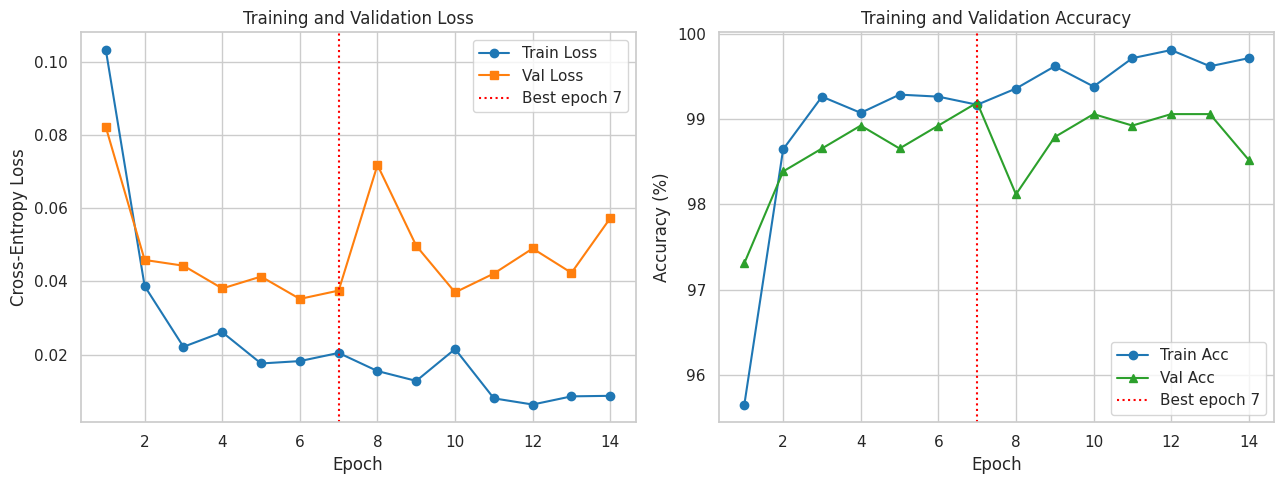

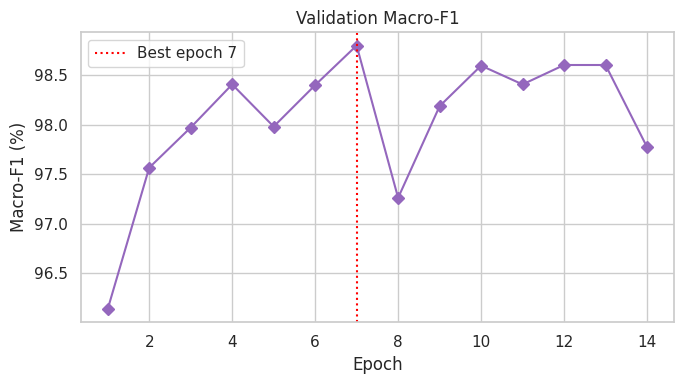

,Class,Precision,Recall,F1-Score,Support
0,No Tumor,0.965035,0.992806,0.978723,139
1,Tumor,0.998826,0.994159,0.996487,856


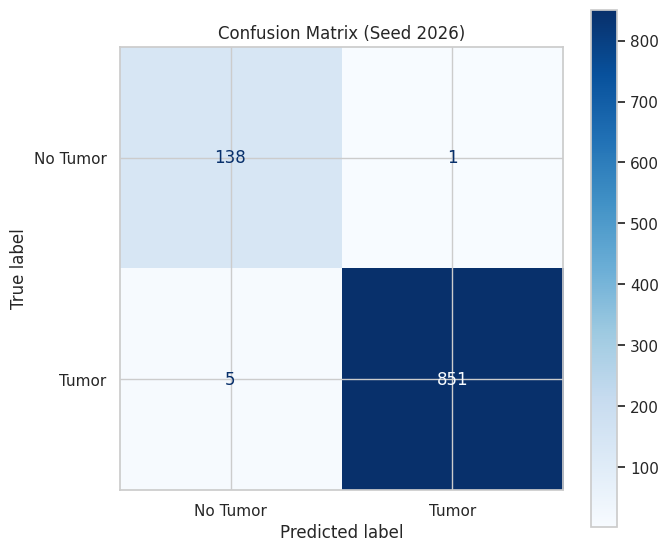

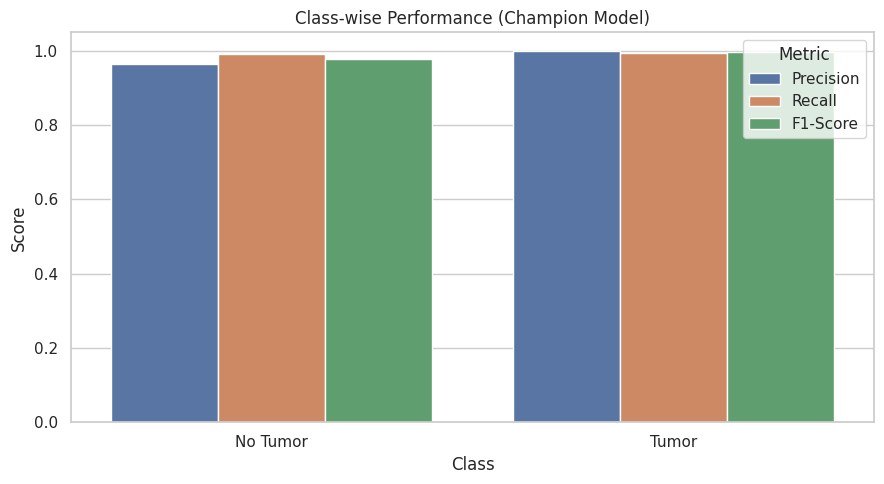

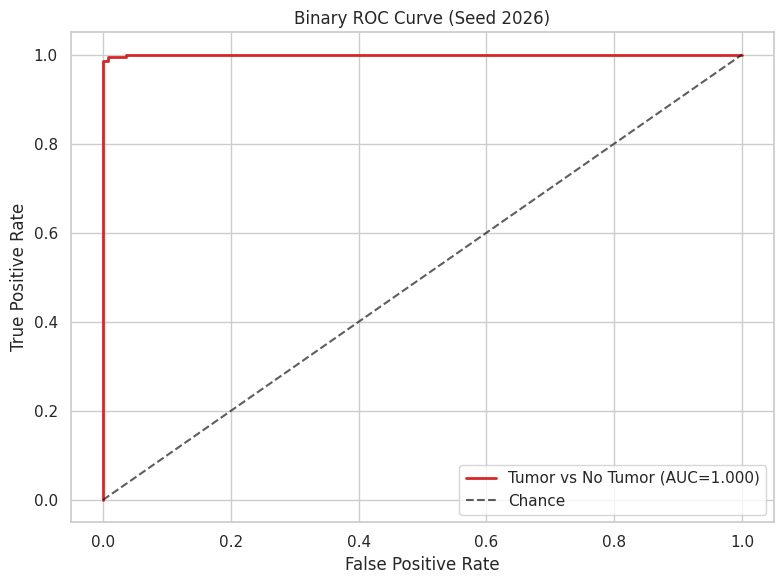

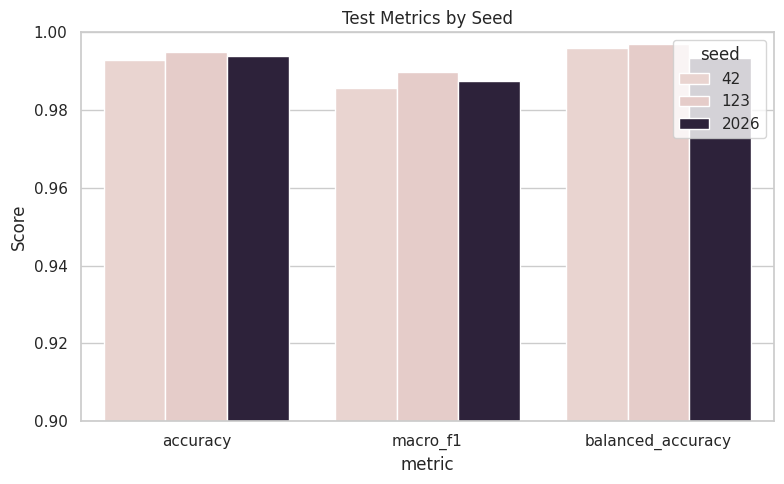

Figures saved to results_dinov3_binary_medically_defensible/figures


In [11]:
sns.set_theme(style="whitegrid")
final_history = histories_by_seed[FINAL_SEED]
epochs = range(1, len(final_history["train_loss"]) + 1)

# 1) Training loss + accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs, final_history["train_loss"], "o-", label="Train Loss", color="#1f77b4")
axes[0].plot(epochs, final_history["val_loss"], "s-", label="Val Loss", color="#ff7f0e")
axes[0].axvline(FINAL_EPOCH, color="red", linestyle=":", label=f"Best epoch {FINAL_EPOCH}")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[1].plot(epochs, np.array(final_history["train_acc"]) * 100, "o-", label="Train Acc", color="#1f77b4")
axes[1].plot(epochs, np.array(final_history["val_acc"]) * 100, "^-", label="Val Acc", color="#2ca02c")
axes[1].axvline(FINAL_EPOCH, color="red", linestyle=":", label=f"Best epoch {FINAL_EPOCH}")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"training_curves_final_model.{ext}", dpi=300, bbox_inches="tight")
plt.show()

# 2) Validation macro-F1 curve
plt.figure(figsize=(7, 4))
plt.plot(epochs, np.array(final_history["val_macro_f1"]) * 100, "D-", color="#9467bd")
plt.axvline(FINAL_EPOCH, color="red", linestyle=":", label=f"Best epoch {FINAL_EPOCH}")
plt.title("Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1 (%)")
plt.legend()
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"validation_macro_f1_curve.{ext}", dpi=300, bbox_inches="tight")
plt.show()

final_preds = predictions_by_seed[FINAL_SEED]
final_labels = labels_by_seed[FINAL_SEED]
final_probs = probabilities_by_seed[FINAL_SEED]
report = classification_report(final_labels, final_preds, target_names=CLASS_DISPLAY, output_dict=True, zero_division=0)
per_class = pd.DataFrame(
    [
        {
            "Class": c,
            "Precision": report[c]["precision"],
            "Recall": report[c]["recall"],
            "F1-Score": report[c]["f1-score"],
            "Support": int(report[c]["support"]),
        }
        for c in CLASS_DISPLAY
    ]
)
per_class.to_csv(METRICS_DIR / "per_class_test_metrics.csv", index=False)
display(per_class)

# 3) Confusion matrix
cm = confusion_matrix(final_labels, final_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_DISPLAY).plot(
    cmap=plt.cm.Blues, ax=ax, values_format="d", colorbar=True
)
ax.set_title(f"Confusion Matrix (Seed {FINAL_SEED})")
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"confusion_matrix_final_model.{ext}", dpi=300, bbox_inches="tight")
plt.show()

# 4) Class-wise bar chart
plot_df = per_class.melt(id_vars="Class", value_vars=["Precision", "Recall", "F1-Score"], var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Class", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Class-wise Performance (Champion Model)")
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"classwise_performance_bar.{ext}", dpi=300, bbox_inches="tight")
plt.show()

# 5) ROC curve (tumor = positive class)
tumor_idx = CLASS_TO_IDX["tumor"]
fpr, tpr, _ = roc_curve(final_labels, final_probs[:, tumor_idx], pos_label=tumor_idx)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, color="#d62728", label=f"Tumor vs No Tumor (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Binary ROC Curve (Seed {FINAL_SEED})")
plt.legend(loc="lower right")
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"roc_curve_final_model.{ext}", dpi=300, bbox_inches="tight")
plt.show()

# 6) Multi-seed test metrics
plt.figure(figsize=(8, 5))
plot_metrics = df_test.melt(
    id_vars=["seed", "is_champion"],
    value_vars=["accuracy", "macro_f1", "balanced_accuracy"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=plot_metrics, x="metric", y="value", hue="seed")
plt.ylim(0.9, 1.0)
plt.title("Test Metrics by Seed")
plt.ylabel("Score")
plt.tight_layout()
for ext in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"test_metrics_by_seed.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Figures saved to", FIG_DIR)


## Optional: 5-Fold Cross-Validation
Runs on the cleaned training pool only (test set excluded). Set `RUN_5FOLD_CV = False` to skip.


CV fold 1/5


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold-1] Ep 01 | TrLoss=0.1029 TrAcc=96.01% | ValLoss=0.0765 ValAcc=97.17% ValF1=95.60% *BEST*
[fold-1] Ep 02 | TrLoss=0.0538 TrAcc=98.21% | ValLoss=0.0573 ValAcc=97.98% ValF1=97.06% *BEST*
[fold-1] Ep 03 | TrLoss=0.0301 TrAcc=99.19% | ValLoss=0.0410 ValAcc=98.79% ValF1=98.21% *BEST*
[fold-1] Ep 05 | TrLoss=0.0199 TrAcc=99.32% | ValLoss=0.0272 ValAcc=99.09% ValF1=98.64% *BEST*
[fold-1] Ep 06 | TrLoss=0.0141 TrAcc=99.50% | ValLoss=0.0207 ValAcc=99.39% ValF1=99.09% *BEST*
[fold-1] Ep 10 | TrLoss=0.0094 TrAcc=99.57% | ValLoss=0.0223 ValAcc=99.39% ValF1=99.09% patience 4/7
[fold-1] Ep 13 | TrLoss=0.0035 TrAcc=99.92% | ValLoss=0.0222 ValAcc=99.39% ValF1=99.10% *BEST*
[fold-1] Ep 14 | TrLoss=0.0071 TrAcc=99.72% | ValLoss=0.0224 ValAcc=99.60% ValF1=99.40% *BEST*
[fold-1] Ep 15 | TrLoss=0.0084 TrAcc=99.62% | ValLoss=0.0220 ValAcc=99.39% ValF1=99.09% patience 1/7
[fold-1] Ep 19 | TrLoss=0.0023 TrAcc=99.97% | ValLoss=0.0223 ValAcc=99.60% ValF1=99.40% *BEST*
[fold-1] Ep 20 | TrLoss=0.0028 TrAcc=9

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold-2] Ep 01 | TrLoss=0.1087 TrAcc=95.64% | ValLoss=0.0430 ValAcc=98.89% ValF1=98.36% *BEST*
[fold-2] Ep 05 | TrLoss=0.0220 TrAcc=99.09% | ValLoss=0.0370 ValAcc=98.28% ValF1=97.39% patience 4/7
[fold-2] Ep 06 | TrLoss=0.0152 TrAcc=99.42% | ValLoss=0.0249 ValAcc=99.29% ValF1=98.94% *BEST*
[fold-2] Ep 10 | TrLoss=0.0147 TrAcc=99.50% | ValLoss=0.0217 ValAcc=99.39% ValF1=99.10% *BEST*
[fold-2] Ep 15 | TrLoss=0.0165 TrAcc=99.32% | ValLoss=0.0501 ValAcc=98.08% ValF1=97.23% patience 5/7
[fold-2] Ep 16 | TrLoss=0.0217 TrAcc=99.34% | ValLoss=0.0155 ValAcc=99.50% ValF1=99.24% *BEST*
[fold-2] Ep 18 | TrLoss=0.0069 TrAcc=99.82% | ValLoss=0.0144 ValAcc=99.50% ValF1=99.25% *BEST*
[fold-2] Ep 20 | TrLoss=0.0082 TrAcc=99.72% | ValLoss=0.0236 ValAcc=99.19% ValF1=98.81% patience 2/7
[fold-2] Ep 25 | TrLoss=0.0031 TrAcc=99.90% | ValLoss=0.0204 ValAcc=99.39% ValF1=99.09% patience 7/7
[fold-2] Early stop at epoch 25
CV fold 3/5


...

[fold-3] Ep 01 | TrLoss=0.1091 TrAcc=95.96% | ValLoss=0.0482 ValAcc=98.18% ValF1=97.32% *BEST*
[fold-3] Ep 03 | TrLoss=0.0296 TrAcc=98.94% | ValLoss=0.0388 ValAcc=98.69% ValF1=98.09% *BEST*
[fold-3] Ep 04 | TrLoss=0.0224 TrAcc=99.14% | ValLoss=0.0139 ValAcc=99.60% ValF1=99.40% *BEST*
[fold-3] Ep 05 | TrLoss=0.0266 TrAcc=98.94% | ValLoss=0.0217 ValAcc=99.29% ValF1=98.96% patience 1/7
[fold-3] Ep 08 | TrLoss=0.0144 TrAcc=99.57% | ValLoss=0.0103 ValAcc=99.70% ValF1=99.55% *BEST*
[fold-3] Ep 10 | TrLoss=0.0158 TrAcc=99.47% | ValLoss=0.0123 ValAcc=99.50% ValF1=99.26% patience 2/7
[fold-3] Ep 15 | TrLoss=0.0038 TrAcc=99.90% | ValLoss=0.0071 ValAcc=99.80% ValF1=99.70% *BEST*
[fold-3] Ep 17 | TrLoss=0.0050 TrAcc=99.85% | ValLoss=0.0056 ValAcc=99.90% ValF1=99.85% *BEST*
[fold-3] Ep 19 | TrLoss=0.0038 TrAcc=99.90% | ValLoss=0.0030 ValAcc=100.00% ValF1=100.00% *BEST*
[fold-3] Ep 20 | TrLoss=0.0039 TrAcc=99.90% | ValLoss=0.0055 ValAcc=99.90% ValF1=99.85% patience 1/7
[fold-3] Ep 25 | TrLoss=0.0029

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold-4] Ep 01 | TrLoss=0.1001 TrAcc=96.17% | ValLoss=0.0390 ValAcc=98.59% ValF1=97.90% *BEST*
[fold-4] Ep 02 | TrLoss=0.0454 TrAcc=98.44% | ValLoss=0.0461 ValAcc=98.89% ValF1=98.37% *BEST*
[fold-4] Ep 03 | TrLoss=0.0234 TrAcc=99.17% | ValLoss=0.0288 ValAcc=99.09% ValF1=98.66% *BEST*
[fold-4] Ep 05 | TrLoss=0.0266 TrAcc=99.12% | ValLoss=0.0269 ValAcc=99.09% ValF1=98.64% patience 2/7
[fold-4] Ep 07 | TrLoss=0.0168 TrAcc=99.50% | ValLoss=0.0178 ValAcc=99.50% ValF1=99.25% *BEST*
[fold-4] Ep 10 | TrLoss=0.0132 TrAcc=99.47% | ValLoss=0.0470 ValAcc=98.59% ValF1=97.86% patience 3/7
[fold-4] Early stop at epoch 14
CV fold 5/5


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold-5] Ep 01 | TrLoss=0.1095 TrAcc=95.64% | ValLoss=0.0365 ValAcc=98.99% ValF1=98.50% *BEST*
[fold-5] Ep 02 | TrLoss=0.0461 TrAcc=98.01% | ValLoss=0.0261 ValAcc=99.39% ValF1=99.10% *BEST*
[fold-5] Ep 05 | TrLoss=0.0265 TrAcc=99.02% | ValLoss=0.0471 ValAcc=98.39% ValF1=97.65% patience 3/7
[fold-5] Ep 08 | TrLoss=0.0142 TrAcc=99.45% | ValLoss=0.0204 ValAcc=99.39% ValF1=99.10% *BEST*
[fold-5] Ep 10 | TrLoss=0.0155 TrAcc=99.45% | ValLoss=0.0366 ValAcc=98.89% ValF1=98.33% patience 2/7
[fold-5] Ep 13 | TrLoss=0.0121 TrAcc=99.42% | ValLoss=0.0193 ValAcc=99.39% ValF1=99.10% *BEST*
[fold-5] Ep 14 | TrLoss=0.0071 TrAcc=99.80% | ValLoss=0.0139 ValAcc=99.50% ValF1=99.25% *BEST*
[fold-5] Ep 15 | TrLoss=0.0038 TrAcc=99.90% | ValLoss=0.0151 ValAcc=99.19% ValF1=98.79% patience 1/7
[fold-5] Ep 17 | TrLoss=0.0071 TrAcc=99.82% | ValLoss=0.0145 ValAcc=99.60% ValF1=99.40% *BEST*
[fold-5] Ep 20 | TrLoss=0.0063 TrAcc=99.80% | ValLoss=0.0150 ValAcc=99.50% ValF1=99.25% patience 3/7
[fold-5] Ep 21 | TrLoss=0.

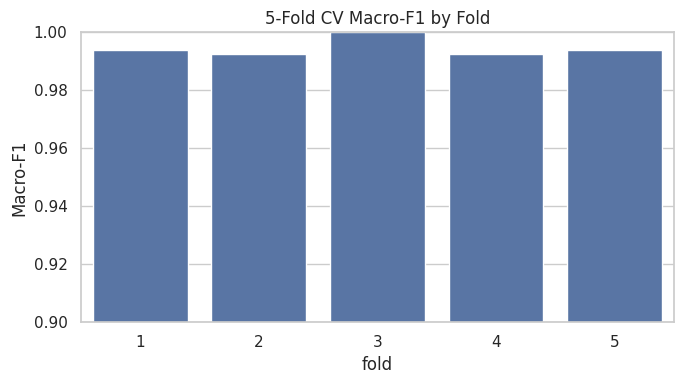

In [12]:
RUN_5FOLD_CV = True

if RUN_5FOLD_CV:
    skf = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["cv_seed"])
    fps_arr = np.array(clean_train_fps)
    lbl_arr = np.array(clean_train_labels_int)
    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(fps_arr, lbl_arr)):
        print(f"CV fold {fold + 1}/{CONFIG['cv_folds']}")
        set_seed(CONFIG["cv_seed"] + fold)
        tr_loader = DataLoader(
            ImageListDataset(fps_arr[tr_idx].tolist(), lbl_arr[tr_idx].tolist(), transform_train),
            batch_size=CONFIG["batch_size"],
            shuffle=True,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        )
        va_loader = DataLoader(
            ImageListDataset(fps_arr[va_idx].tolist(), lbl_arr[va_idx].tolist(), transform_eval),
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        )
        backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
        model = DINOv3Classifier(backbone, CONFIG["hidden_dim"], NUM_CLASSES, CONFIG["dropout"]).to(device)
        unfreeze_last_n_blocks(model, CONFIG["n_unfreeze_blocks"])
        bb = [p for n, p in model.named_parameters() if "head" not in n and p.requires_grad]
        opt = optim.Adam(
            [
                {"params": bb, "lr": CONFIG["lr_backbone"]},
                {"params": model.head.parameters(), "lr": CONFIG["lr_head"]},
            ],
            weight_decay=CONFIG["weight_decay"],
        )
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
        model, _, _, _, _ = train_model(
            model,
            tr_loader,
            va_loader,
            opt,
            sch,
            criterion,
            CONFIG["epochs_finetune"],
            CONFIG["patience"],
            desc=f"fold-{fold + 1}",
        )
        _, _, _, m = evaluate_dataset(model, va_loader)
        fold_rows.append({"fold": fold + 1, **m})
        del model, backbone, tr_loader, va_loader
        torch.cuda.empty_cache()
    df_cv = pd.DataFrame(fold_rows)
    df_cv.to_csv(METRICS_DIR / "cross_validation_results.csv", index=False)
    cv_mean = df_cv["macro_f1"].mean() * 100
    cv_std = df_cv["macro_f1"].std(ddof=1) * 100
    print(f"CV macro-F1: {cv_mean:.2f}% +/- {cv_std:.2f}%")
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_cv, x="fold", y="macro_f1", color="#4c72b0")
    plt.ylim(0.9, 1.0)
    plt.ylabel("Macro-F1")
    plt.title("5-Fold CV Macro-F1 by Fold")
    plt.tight_layout()
    for ext in ["png", "pdf"]:
        plt.savefig(FIG_DIR / f"cv_macro_f1_by_fold.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Skipped 5-fold CV")


## Done

**Artifacts**
- `results_dinov3_binary_medically_defensible/dinov3_binary_medically_defensible_final.pth`
- `results_dinov3_binary_medically_defensible/metrics/*.csv`
- `results_dinov3_binary_medically_defensible/figures/*.png` and `.pdf`

**Binary label mapping**
- `no_tumor` ← original no_tumor class
- `tumor` ← glioma + meningioma + pituitary

**Paper figure mapping**
- `training_curves_final_model.png` → training/validation loss and accuracy
- `classwise_performance_bar.png` → class-wise precision/recall/F1
- `confusion_matrix_final_model.png` → binary confusion matrix
- `roc_curve_final_model.png` → binary ROC curve (tumor positive)
- `cv_macro_f1_by_fold.png` → 5-fold CV plot


In [13]:
import shutil

# Define the destination path in Google Drive
DRIVE_SAVE_PATH = "/content/drive/MyDrive/dinov3_binary_results_saved"

# Create the destination directory if it doesn't exist
if not os.path.exists(DRIVE_SAVE_PATH):
    os.makedirs(DRIVE_SAVE_PATH)

# Copy the entire OUT_ROOT directory to Google Drive
shutil.copytree(OUT_ROOT, DRIVE_SAVE_PATH, dirs_exist_ok=True)

print(f"All results from '{OUT_ROOT}' saved to '{DRIVE_SAVE_PATH}' in Google Drive.")

All results from 'results_dinov3_binary_medically_defensible' saved to '/content/drive/MyDrive/dinov3_binary_results_saved' in Google Drive.


## Results Saved to Google Drive

All generated artifacts (checkpoints, figures, metrics, and the final model) have been successfully saved to your Google Drive at:

`/content/drive/MyDrive/dinov3_binary_results_saved/`